In [ ]:
# HÜCRE 1 — Kütüphaneler
import numpy as np
import pandas as pd

from google.colab import files

from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, matthews_corrcoef, confusion_matrix


In [ ]:
# HÜCRE 2 — Veri yükleme
uploaded = files.upload()


Saving test_data.txt to test_data.txt
Saving train_data.txt to train_data.txt


In [ ]:
# HÜCRE 3 — Veriyi okuma
feature_names = [
    "Jitter_local", "Jitter_local_abs", "Jitter_rap", "Jitter_ppq5", "Jitter_ddp",
    "Shimmer_local", "Shimmer_local_dB", "Shimmer_apq3", "Shimmer_apq5", "Shimmer_apq11", "Shimmer_dda",
    "AC", "NTH", "HTN",
    "Median_pitch", "Mean_pitch", "Pitch_std", "Min_pitch", "Max_pitch",
    "Num_pulses", "Num_periods", "Mean_period", "Period_std",
    "Frac_unvoiced_frames", "Num_voice_breaks", "Degree_voice_breaks"
]

train_cols = ["subject_id"] + feature_names + ["UPDRS", "class"]
test_cols = ["subject_id"] + feature_names + ["class"]

train_df = pd.read_csv("train_data.txt", header=None, names=train_cols)
test_df = pd.read_csv("test_data.txt", header=None, names=test_cols)

train_df["sample_index"] = np.tile(np.arange(1, 27), len(train_df) // 26)

def sample_type(idx):
    if idx <= 3:
        return "vowel"
    elif idx <= 13:
        return "number"
    elif idx <= 17:
        return "sentence"
    else:
        return "word"

train_df["sample_type"] = train_df["sample_index"].apply(sample_type)

print(train_df.head())
print(train_df.shape)


   subject_id  Jitter_local  Jitter_local_abs  Jitter_rap  Jitter_ppq5  \
0           1         1.488          0.000090       0.900        0.794   
1           1         0.728          0.000038       0.353        0.376   
2           1         1.220          0.000074       0.732        0.670   
3           1         2.502          0.000123       1.156        1.634   
4           1         3.509          0.000167       1.715        1.539   

   Jitter_ddp  Shimmer_local  Shimmer_local_dB  Shimmer_apq3  Shimmer_apq5  \
0       2.699          8.334             0.779         4.517         4.609   
1       1.059          5.864             0.642         2.058         3.180   
2       2.196          8.719             0.875         4.347         5.166   
3       3.469         13.513             1.273         5.263         8.771   
4       5.145          9.112             1.040         3.102         4.927   

   ...  Num_periods  Mean_period  Period_std  Frac_unvoiced_frames  \
0  ...          

In [ ]:
# HÜCRE 4 — Metrics
def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        "accuracy": acc,
        "mcc": mcc,
        "sensitivity": sensitivity,
        "specificity": specificity
    }


In [ ]:
def compute_weights(df):
    X = df[feature_names].copy()

    med = X.median()
    mad = (X - med).abs().median().replace(0, 1e-6)

    robust_z = ((X - med).abs() / mad)
    score = robust_z.mean(axis=1).values

    weights = np.exp(-score)

    # 🔥 YENİ KISIM (ASIL FARK BURADA)
    type_weights = []

    for t in df["sample_type"]:
        if t == "vowel":
            type_weights.append(1.5)   # en önemli
        elif t == "number":
            type_weights.append(1.2)
        else:
            type_weights.append(1.0)

    weights = weights * np.array(type_weights)

    return weights / weights.sum()

In [ ]:
# HÜCRE 6 — Subject aggregation
def build_subject_dataset_from_df(df):
    rows = []

    for sid, g in df.groupby("subject_id"):
        row = {"subject_id": sid, "class": int(g["class"].iloc[0])}

        w = compute_weights(g)

        for f in feature_names:
            x = g[f].values
            wmean = np.sum(w * x)
            wstd = np.sqrt(np.sum(w * (x - wmean) ** 2))

            row[f + "_wmean"] = wmean
            row[f + "_wstd"] = wstd

        rows.append(row)

    return pd.DataFrame(rows)


In [ ]:
def evaluate_weighted_proper(k=5, C=1, gamma=0.01, class_weight="balanced"):
    subjects = train_df["subject_id"].unique()

    y_true, y_pred = [], []

    for test_sid in subjects:
        train_part = train_df[train_df["subject_id"] != test_sid].copy()
        test_part  = train_df[train_df["subject_id"] == test_sid].copy()

        train_subj = build_subject_dataset_from_df(train_part)
        test_subj  = build_subject_dataset_from_df(test_part)

        X_train = train_subj.drop(columns=["subject_id", "class"])
        y_train = train_subj["class"].values

        X_test = test_subj.drop(columns=["subject_id", "class"])
        y_test = test_subj["class"].values

        scaler = RobustScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        selector = SelectKBest(mutual_info_classif, k=k)
        X_train_sel = selector.fit_transform(X_train_scaled, y_train)
        X_test_sel = selector.transform(X_test_scaled)

        model = SVC(
            kernel="rbf",
            C=C,
            gamma=gamma,
            class_weight=class_weight
        )

        model.fit(X_train_sel, y_train)
        pred = model.predict(X_test_sel)[0]

        y_true.append(y_test[0])
        y_pred.append(pred)

    return compute_metrics(y_true, y_pred)

In [ ]:
print("DENEME 1")
print(evaluate_weighted_proper(k=5, C=1, gamma=0.01, class_weight="balanced"))

print("\nDENEME 2")
print(evaluate_weighted_proper(k=7, C=1, gamma=0.01, class_weight="balanced"))

print("\nDENEME 3")
print(evaluate_weighted_proper(k=10, C=1, gamma=0.01, class_weight="balanced"))

DENEME 1
{'accuracy': 0.775, 'mcc': np.float64(0.5871365639519862), 'sensitivity': np.float64(0.6), 'specificity': np.float64(0.95)}

DENEME 2
{'accuracy': 0.875, 'mcc': np.float64(0.7585826061362605), 'sensitivity': np.float64(0.8), 'specificity': np.float64(0.95)}

DENEME 3
{'accuracy': 0.85, 'mcc': np.float64(0.7035264706814485), 'sensitivity': np.float64(0.8), 'specificity': np.float64(0.9)}


In [ ]:
def compute_weights_learnable(df, vowel_w=1.5, number_w=1.2, other_w=1.0):
    X = df[feature_names].copy()

    med = X.median()
    mad = (X - med).abs().median().replace(0, 1e-6)

    robust_z = ((X - med).abs() / mad)
    score = robust_z.mean(axis=1).values

    weights = np.exp(-score)

    type_weights = []
    for t in df["sample_type"]:
        if t == "vowel":
            type_weights.append(vowel_w)
        elif t == "number":
            type_weights.append(number_w)
        else:
            type_weights.append(other_w)

    weights = weights * np.array(type_weights)
    return weights / weights.sum()

In [ ]:
def build_subject_dataset_learnable(df, vowel_w=1.5, number_w=1.2, other_w=1.0):
    rows = []

    for sid, g in df.groupby("subject_id"):
        row = {"subject_id": sid, "class": int(g["class"].iloc[0])}

        w = compute_weights_learnable(
            g,
            vowel_w=vowel_w,
            number_w=number_w,
            other_w=other_w
        )

        for f in feature_names:
            x = g[f].values
            wmean = np.sum(w * x)
            wstd = np.sqrt(np.sum(w * (x - wmean) ** 2))

            row[f + "_wmean"] = wmean
            row[f + "_wstd"] = wstd

        rows.append(row)

    return pd.DataFrame(rows)

In [ ]:
def evaluate_weighted_learnable(
    vowel_w=1.5,
    number_w=1.2,
    other_w=1.0,
    k=7,
    C=1,
    gamma=0.01,
    class_weight="balanced"
):
    subjects = train_df["subject_id"].unique()

    y_true, y_pred = [], []

    for test_sid in subjects:
        train_part = train_df[train_df["subject_id"] != test_sid].copy()
        test_part  = train_df[train_df["subject_id"] == test_sid].copy()

        train_subj = build_subject_dataset_learnable(
            train_part,
            vowel_w=vowel_w,
            number_w=number_w,
            other_w=other_w
        )
        test_subj = build_subject_dataset_learnable(
            test_part,
            vowel_w=vowel_w,
            number_w=number_w,
            other_w=other_w
        )

        X_train = train_subj.drop(columns=["subject_id", "class"])
        y_train = train_subj["class"].values

        X_test = test_subj.drop(columns=["subject_id", "class"])
        y_test = test_subj["class"].values

        scaler = RobustScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        selector = SelectKBest(mutual_info_classif, k=k)
        X_train_sel = selector.fit_transform(X_train_scaled, y_train)
        X_test_sel = selector.transform(X_test_scaled)

        model = SVC(
            kernel="rbf",
            C=C,
            gamma=gamma,
            class_weight=class_weight
        )

        model.fit(X_train_sel, y_train)
        pred = model.predict(X_test_sel)[0]

        y_true.append(y_test[0])
        y_pred.append(pred)

    return compute_metrics(y_true, y_pred)

In [ ]:
search_results = []

vowel_values = [1.0, 1.2, 1.5, 1.8, 2.0]
number_values = [1.0, 1.1, 1.2, 1.4, 1.6]
other_values = [0.8, 1.0]

for vw in vowel_values:
    for nw in number_values:
        for ow in other_values:
            res = evaluate_weighted_learnable(
                vowel_w=vw,
                number_w=nw,
                other_w=ow,
                k=7,
                C=1,
                gamma=0.01,
                class_weight="balanced"
            )
            res["vowel_w"] = vw
            res["number_w"] = nw
            res["other_w"] = ow
            search_results.append(res)

df_search = pd.DataFrame(search_results).sort_values(
    by=["accuracy", "mcc"],
    ascending=False
)

df_search.head(20)

,accuracy,mcc,sensitivity,specificity,vowel_w,number_w,other_w
10,0.875,0.758583,0.80,0.95,1.2,1.0,0.8
23,0.875,0.758583,0.80,0.95,1.5,1.1,1.0
25,0.875,0.758583,0.80,0.95,1.5,1.2,1.0
20,0.850,0.714435,0.75,0.95,1.5,1.0,0.8
22,0.850,0.714435,0.75,0.95,1.5,1.1,0.8
40,0.850,0.714435,0.75,0.95,2.0,1.0,0.8
47,0.850,0.714435,0.75,0.95,2.0,1.4,1.0
0,0.825,0.671317,0.70,0.95,1.0,1.0,0.8
8,0.825,0.671317,0.70,0.95,1.0,1.6,0.8
21,0.825,0.671317,0.70,0.95,1.5,1.0,1.0


In [ ]:
from collections import Counter

def analyze_selected_features(
    k=7,
    C=1,
    gamma=0.01,
    class_weight="balanced"
):
    subjects = train_df["subject_id"].unique()

    selected_counter = Counter()

    for test_sid in subjects:
        train_part = train_df[train_df["subject_id"] != test_sid].copy()
        test_part  = train_df[train_df["subject_id"] == test_sid].copy()

        train_subj = build_subject_dataset_from_df(train_part)
        test_subj  = build_subject_dataset_from_df(test_part)

        X_train = train_subj.drop(columns=["subject_id", "class"])
        y_train = train_subj["class"].values

        X_test = test_subj.drop(columns=["subject_id", "class"])
        y_test = test_subj["class"].values

        feature_cols = X_train.columns.tolist()

        scaler = RobustScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        selector = SelectKBest(mutual_info_classif, k=k)
        X_train_sel = selector.fit_transform(X_train_scaled, y_train)
        X_test_sel = selector.transform(X_test_scaled)

        selected_mask = selector.get_support()
        selected_features = [f for f, keep in zip(feature_cols, selected_mask) if keep]

        selected_counter.update(selected_features)

    result_df = pd.DataFrame(
        selected_counter.items(),
        columns=["feature", "selected_count"]
    ).sort_values(by="selected_count", ascending=False)

    result_df["selection_rate"] = result_df["selected_count"] / len(subjects)

    return result_df

In [ ]:
selected_df = analyze_selected_features(
    k=7,
    C=1,
    gamma=0.01,
    class_weight="balanced"
)

selected_df.head(20)

,feature,selected_count,selection_rate
0,Shimmer_apq11_wmean,40,1.000
5,Degree_voice_breaks_wmean,40,1.000
4,Num_voice_breaks_wstd,40,1.000
6,Degree_voice_breaks_wstd,40,1.000
2,Frac_unvoiced_frames_wstd,39,0.975
3,Num_voice_breaks_wmean,37,0.925
7,HTN_wstd,19,0.475
1,Mean_pitch_wstd,9,0.225
10,NTH_wstd,9,0.225
9,Frac_unvoiced_frames_wmean,5,0.125


In [ ]:
def get_base_feature_name(feature_name):
    if feature_name.endswith("_wmean"):
        return feature_name.replace("_wmean", "")
    elif feature_name.endswith("_wstd"):
        return feature_name.replace("_wstd", "")
    return feature_name

selected_df["base_feature"] = selected_df["feature"].apply(get_base_feature_name)
selected_df["stat_type"] = selected_df["feature"].apply(
    lambda x: "wmean" if x.endswith("_wmean") else ("wstd" if x.endswith("_wstd") else "other")
)

grouped_base = selected_df.groupby("base_feature", as_index=False)["selected_count"].sum()
grouped_base = grouped_base.sort_values(by="selected_count", ascending=False)

grouped_stat = selected_df.groupby("stat_type", as_index=False)["selected_count"].sum()

print("BASE FEATURE ÖNEM SIRASI")
display(grouped_base.head(15))

print("\nSTAT TYPE DAĞILIMI")
display(grouped_stat)

BASE FEATURE ÖNEM SIRASI


,base_feature,selected_count
0,Degree_voice_breaks,80
6,Num_voice_breaks,77
1,Frac_unvoiced_frames,44
7,Shimmer_apq11,40
2,HTN,19
5,NTH,9
4,Mean_pitch,9
3,Mean_period,2



STAT TYPE DAĞILIMI


,stat_type,selected_count
0,wmean,122
1,wstd,158


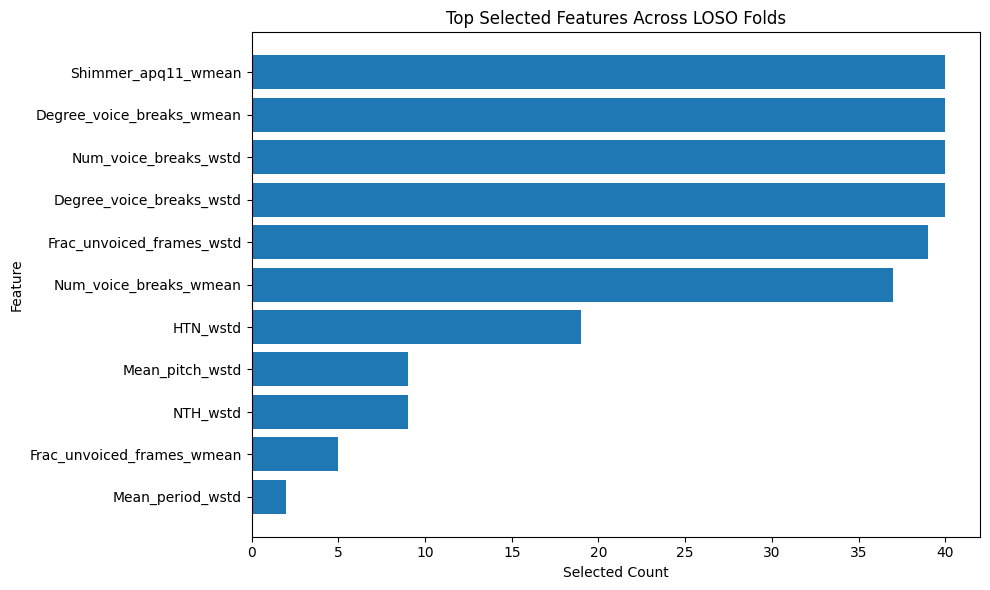

In [ ]:
import matplotlib.pyplot as plt

top_n = 15
plot_df = selected_df.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["feature"][::-1], plot_df["selected_count"][::-1])
plt.xlabel("Selected Count")
plt.ylabel("Feature")
plt.title("Top Selected Features Across LOSO Folds")
plt.tight_layout()
plt.show()

In [ ]:
# ==============================================
# ARAYÜZ İÇİN: Eğitim verisini ve fonksiyonları
# diske kaydet
# ==============================================

import joblib

# 1. EĞİTİM VERİSİNİ KAYDET (Honest mod için lazım)
# Çünkü her tahminde 39 özne ile yeniden eğitim yapacağız
joblib.dump(train_df, "train_df_robust.pkl")
print("✓ train_df_robust.pkl kaydedildi")

# 2. HİPERPARAMETRELERİ KAYDET
config_robust = {
    "model_name": "Robust Ağırlıklı Özetleme",
    "thesis_section": "3.5",
    "vowel_w": 1.5,
    "number_w": 1.2,
    "other_w": 1.0,
    "k": 7,
    "C": 1,
    "gamma": 0.01,
    "kernel": "rbf",
    "class_weight": "balanced",
    "thesis_accuracy": 0.875,
    "thesis_mcc": 0.7586,
    "feature_names": feature_names
}

joblib.dump(config_robust, "config_robust.pkl")
print("✓ config_robust.pkl kaydedildi")

print("\nTOPLAM:")
print(f"   train_df boyut: {train_df.shape}")
print(f"   Özne sayısı: {train_df['subject_id'].nunique()}")

✓ train_df_robust.pkl kaydedildi
✓ config_robust.pkl kaydedildi

TOPLAM:
   train_df boyut: (1040, 31)
   Özne sayısı: 40


In [ ]:
# ==============================================
# ARAYÜZÜN KULLANACAĞI HONEST TAHMİN FONKSİYONU
# Bir özneyi dışarıda tutar, kalan 39 ile eğitir
# ==============================================

def predict_honest_robust(test_subject_id, train_df_full, config):
    """
    Honest s-LOO tahmin: Test öznesini dışarıda tutar.

    Parametreler:
    -----------
    test_subject_id : int
        Test edilecek öznenin ID'si (1-40)
    train_df_full : DataFrame
        Tüm eğitim verisi (40 özne)
    config : dict
        Hiperparametreler

    Döner:
    ------
    dict : Tahmin sonuçları
    """

    # 1. Test öznesini ayır
    train_part = train_df_full[train_df_full["subject_id"] != test_subject_id].copy()
    test_part = train_df_full[train_df_full["subject_id"] == test_subject_id].copy()

    if len(test_part) == 0:
        return {"error": f"Özne {test_subject_id} bulunamadı"}

    actual_class = int(test_part["class"].iloc[0])

    # 2. 39 özne ile özetleme
    train_subj = build_subject_dataset_learnable(
        train_part,
        vowel_w=config["vowel_w"],
        number_w=config["number_w"],
        other_w=config["other_w"]
    )
    test_subj = build_subject_dataset_learnable(
        test_part,
        vowel_w=config["vowel_w"],
        number_w=config["number_w"],
        other_w=config["other_w"]
    )

    X_train = train_subj.drop(columns=["subject_id", "class"])
    y_train = train_subj["class"].values

    X_test = test_subj.drop(columns=["subject_id", "class"])

    # 3. Ön işleme
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 4. Özellik seçimi
    selector = SelectKBest(mutual_info_classif, k=config["k"])
    X_train_sel = selector.fit_transform(X_train_scaled, y_train)
    X_test_sel = selector.transform(X_test_scaled)

    # 5. SVM eğit (probability=True ile - güven yüzdesi için)
    model = SVC(
        kernel=config["kernel"],
        C=config["C"],
        gamma=config["gamma"],
        class_weight=config["class_weight"],
        probability=True
    )
    model.fit(X_train_sel, y_train)

    # 6. Tahmin
    prediction = int(model.predict(X_test_sel)[0])
    probabilities = model.predict_proba(X_test_sel)[0]

    predicted_label = "Parkinson Hastası (PD)" if prediction == 1 else "Sağlıklı Kontrol (HC)"
    actual_label = "Parkinson Hastası (PD)" if actual_class == 1 else "Sağlıklı Kontrol (HC)"
    is_correct = (prediction == actual_class)

    return {
        "subject_id": test_subject_id,
        "prediction": prediction,
        "predicted_label": predicted_label,
        "actual_class": actual_class,
        "actual_label": actual_label,
        "is_correct": is_correct,
        "confidence": float(probabilities[prediction]),
        "probabilities": {
            "HC": float(probabilities[0]),
            "PD": float(probabilities[1])
        }
    }


# Test edelim - Özne 1 (PD)
print("=" * 60)
print("HONEST TAHMİN TESTİ - Özne 1")
print("=" * 60)

result_1 = predict_honest_robust(
    test_subject_id=1,
    train_df_full=train_df,
    config=config_robust
)

print(f"Tahmin: {result_1['predicted_label']}")
print(f"Gerçek: {result_1['actual_label']}")
print(f"Doğru mu: {'✓ EVET' if result_1['is_correct'] else '✗ HAYIR'}")
print(f"Güven: %{result_1['confidence']*100:.2f}")

# Özne 25 (HC)
print("\n" + "=" * 60)
print("HONEST TAHMİN TESTİ - Özne 25")
print("=" * 60)

result_25 = predict_honest_robust(
    test_subject_id=25,
    train_df_full=train_df,
    config=config_robust
)

print(f"Tahmin: {result_25['predicted_label']}")
print(f"Gerçek: {result_25['actual_label']}")
print(f"Doğru mu: {'✓ EVET' if result_25['is_correct'] else '✗ HAYIR'}")
print(f"Güven: %{result_25['confidence']*100:.2f}")

HONEST TAHMİN TESTİ - Özne 1
Tahmin: Parkinson Hastası (PD)
Gerçek: Parkinson Hastası (PD)
Doğru mu: ✓ EVET
Güven: %90.59

HONEST TAHMİN TESTİ - Özne 25
Tahmin: Sağlıklı Kontrol (HC)
Gerçek: Sağlıklı Kontrol (HC)
Doğru mu: ✓ EVET
Güven: %92.08


In [ ]:
# ==============================================
# DOSYALARI YEREL BİLGİSAYARA İNDİR
# ==============================================

from google.colab import files

print("Dosyalar indiriliyor...")
files.download("train_df_robust.pkl")
files.download("config_robust.pkl")

print("\n✓ TAMAMLANDI!")
print("İndirilen dosyalar:")
print("  1. train_df_robust.pkl   (Eğitim verisi)")
print("  2. config_robust.pkl     (Hiperparametreler)")
print("\nBu dosyaları Flask arayüzünün 'model/' klasörüne koyacağız.")

Dosyalar indiriliyor...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ TAMAMLANDI!
İndirilen dosyalar:
  1. train_df_robust.pkl   (Eğitim verisi)
  2. config_robust.pkl     (Hiperparametreler)

Bu dosyaları Flask arayüzünün 'model/' klasörüne koyacağız.


In [ ]:
# ==============================================
# TEZİN YAZILIM/DONANIM BÖLÜMÜ İÇİN
# Gerçek sürümleri kayıt altına al
# ==============================================

import sys
import platform

print("=" * 60)
print("YAZILIM ORTAMI - SÜRÜM BİLGİLERİ")
print("=" * 60)

# Python sürümü
print(f"\nPython: {sys.version.split()[0]}")
print(f"Platform: {platform.platform()}")

# Tüm kütüphane sürümleri
import numpy, pandas, scipy, sklearn, statsmodels
import matplotlib, seaborn
import joblib

libs = {
    "NumPy": numpy.__version__,
    "Pandas": pandas.__version__,
    "SciPy": scipy.__version__,
    "scikit-learn": sklearn.__version__,
    "statsmodels": statsmodels.__version__,
    "Matplotlib": matplotlib.__version__,
    "Seaborn": seaborn.__version__,
    "joblib": joblib.__version__,
}

print("\nKütüphane Sürümleri:")
print("-" * 40)
for name, version in libs.items():
    print(f"  {name:<20} : {version}")

# TensorFlow varsa (Conv1D notebook'unda olacak)
try:
    import tensorflow as tf
    print(f"  {'TensorFlow':<20} : {tf.__version__}")
except ImportError:
    print(f"  {'TensorFlow':<20} : (yüklü değil)")

YAZILIM ORTAMI - SÜRÜM BİLGİLERİ

Python: 3.12.13
Platform: Linux-6.6.122+-x86_64-with-glibc2.35

Kütüphane Sürümleri:
----------------------------------------
  NumPy                : 2.0.2
  Pandas               : 2.2.2
  SciPy                : 1.16.3
  scikit-learn         : 1.6.1
  statsmodels          : 0.14.6
  Matplotlib           : 3.10.0
  Seaborn              : 0.13.2
  joblib               : 1.5.3
  TensorFlow           : 2.20.0


In [ ]:
# ==============================================
# DONANIM BİLGİLERİ
# ==============================================

print("=" * 60)
print("DONANIM ORTAMI - GOOGLE COLAB")
print("=" * 60)

# CPU bilgisi
print("\n[CPU]")
!cat /proc/cpuinfo | grep "model name" | head -1
!cat /proc/cpuinfo | grep "cpu cores" | head -1
!nproc --all

# RAM bilgisi
print("\n[RAM]")
!cat /proc/meminfo | grep "MemTotal"
!cat /proc/meminfo | grep "MemAvailable"

# Disk
print("\n[DISK]")
!df -h / | head -2

# GPU varsa
print("\n[GPU]")
import subprocess
try:
    gpu_info = subprocess.check_output(['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'], stderr=subprocess.DEVNULL).decode()
    print(f"GPU: {gpu_info.strip()}")
except:
    print("GPU bulunamadı (CPU only - SVM için yeterli)")

DONANIM ORTAMI - GOOGLE COLAB

[CPU]
model name	: AMD EPYC 7B12
cpu cores	: 1
2

[RAM]
MemTotal:       13286944 kB
MemAvailable:   11346816 kB

[DISK]
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   21G   88G  19% /

[GPU]
GPU bulunamadı (CPU only - SVM için yeterli)


In [ ]:
# ==============================================
# BIR s-LOO DÖNGÜSÜNÜN SÜRESİNİ ÖLÇ
# Tezdeki "Bir s-LOO döngüsü 5-15 saniye sürer" iddiasını doğrula
# ==============================================

import time

print("=" * 60)
print("s-LOO DÖNGÜSÜ SÜRE ÖLÇÜMÜ")
print("=" * 60)

# Tek bir s-LOO döngüsü (40 iterasyon)
start = time.time()
result = evaluate_weighted_learnable(
    vowel_w=1.5,
    number_w=1.2,
    other_w=1.0,
    k=7,
    C=1,
    gamma=0.01,
    class_weight="balanced"
)
elapsed = time.time() - start

print(f"\nKonfigürasyon: vowel_w=1.5, number_w=1.2, other_w=1.0, k=7")
print(f"Sonuç: Accuracy={result['accuracy']:.4f}, MCC={result['mcc']:.4f}")
print(f"\nSüre: {elapsed:.2f} saniye")
print(f"Bir iterasyon ortalama: {elapsed/40:.3f} saniye")

# Honest tahmin süresi
print("\n" + "=" * 60)
print("HONEST TAHMİN SÜRESİ (1 özne)")
print("=" * 60)

start = time.time()
result = predict_honest_robust(
    test_subject_id=1,
    train_df_full=train_df,
    config=config_robust
)
elapsed = time.time() - start
print(f"\nÖzne 1 için honest tahmin süresi: {elapsed:.2f} saniye")

s-LOO DÖNGÜSÜ SÜRE ÖLÇÜMÜ

Konfigürasyon: vowel_w=1.5, number_w=1.2, other_w=1.0, k=7
Sonuç: Accuracy=0.8750, MCC=0.7586

Süre: 12.25 saniye
Bir iterasyon ortalama: 0.306 saniye

HONEST TAHMİN SÜRESİ (1 özne)

Özne 1 için honest tahmin süresi: 0.27 saniye
